# **Economics of Emissions** 
### Prediction Analysis of the Contribution of Emissions to the GDP of the states in the United States of America using a Cluster-Spatio-Temporal Approach

## - Full Emissions Dataset

### Data Importation

In [2]:
import pandas as pd

# Path to your CSV file
file_path = "Cleaned_Emissions_Yearly.csv"

# IMporting Data
df_full_emissions = pd.read_csv(file_path)

# Data Overview
df_full_emissions.head()

,Country,State,Year,Emission
0,United States,Alabama,1990,42341.939842
1,United States,Alabama,1991,39217.818686
2,United States,Alabama,1992,36762.376140
3,United States,Alabama,1993,36945.520425
4,United States,Alabama,1994,37441.987568


### Data Preparation for PCA

In [3]:
# Converting to wide format
df_full_emissions = df_full_emissions.pivot(index=["Country", "State"], columns="Year", values="Emission")
# Removing the multi-index column name
df_full_emissions.columns.name = None
# Adding "Y" before each year column
df_full_emissions = df_full_emissions.rename(columns=lambda x: f"Y{x}")
# Reseting index
df_full_emissions = df_full_emissions.reset_index()
# Data Overview
df_full_emissions.head()

,Country,State,Y1990,Y1991,Y1992,Y1993,Y1994,Y1995,Y1996,Y1997,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
0,United States,Alabama,42341.939842,39217.818686,36762.376140,36945.520425,37441.987568,40712.673551,40187.225641,41593.527760,...,33187.930936,33533.987021,35577.610487,35041.271517,34406.718229,32957.524763,33419.572431,34900.998182,36319.302964,36199.754160
1,United States,Alaska,13057.979719,12881.879961,12635.665115,12655.041562,12768.739441,13150.596568,13383.873728,12580.704288,...,12716.606270,13305.443830,15505.319583,13908.673747,13063.230496,14306.000920,15030.391277,16006.192835,18833.969118,16456.706282
2,United States,Arizona,11397.070725,10770.333759,10977.466416,11677.534583,11971.541408,9498.925268,9752.536105,10733.783064,...,12257.941789,12191.611173,12310.980596,11954.890654,12665.127577,12937.991352,12630.454500,13269.782334,13338.535031,13624.956654
3,United States,Arkansas,23431.283868,22436.921304,22075.394653,22914.652765,23302.866291,28304.747018,27888.475963,26280.569444,...,22565.961616,22380.122269,22389.758362,22337.305632,22953.187448,22678.984887,22502.949646,23031.602690,23282.774458,23073.616511
4,United States,California,121985.915008,115946.909050,118151.586102,120431.050041,123151.718742,111858.367920,115006.542502,122829.456105,...,109158.490066,107257.713379,107315.235572,105784.009296,108378.655948,109683.174244,106709.259268,111976.553496,113424.533946,112465.628899


In [4]:
import numpy as np

# Subseting the Year Columns (1990–2023)
year_cols = [col for col in df_full_emissions.columns if col.startswith('Y')]
combined_emissions_1990_2023 = df_full_emissions[year_cols].copy()
combined_emissions_1990_2023.head()


,Y1990,Y1991,Y1992,Y1993,Y1994,Y1995,Y1996,Y1997,Y1998,Y1999,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
0,42341.939842,39217.818686,36762.376140,36945.520425,37441.987568,40712.673551,40187.225641,41593.527760,41608.410124,40588.513635,...,33187.930936,33533.987021,35577.610487,35041.271517,34406.718229,32957.524763,33419.572431,34900.998182,36319.302964,36199.754160
1,13057.979719,12881.879961,12635.665115,12655.041562,12768.739441,13150.596568,13383.873728,12580.704288,12493.056127,12814.866996,...,12716.606270,13305.443830,15505.319583,13908.673747,13063.230496,14306.000920,15030.391277,16006.192835,18833.969118,16456.706282
2,11397.070725,10770.333759,10977.466416,11677.534583,11971.541408,9498.925268,9752.536105,10733.783064,11302.708076,11063.962622,...,12257.941789,12191.611173,12310.980596,11954.890654,12665.127577,12937.991352,12630.454500,13269.782334,13338.535031,13624.956654
3,23431.283868,22436.921304,22075.394653,22914.652765,23302.866291,28304.747018,27888.475963,26280.569444,25985.401312,25318.969760,...,22565.961616,22380.122269,22389.758362,22337.305632,22953.187448,22678.984887,22502.949646,23031.602690,23282.774458,23073.616511
4,121985.915008,115946.909050,118151.586102,120431.050041,123151.718742,111858.367920,115006.542502,122829.456105,123739.204490,121545.668535,...,109158.490066,107257.713379,107315.235572,105784.009296,108378.655948,109683.174244,106709.259268,111976.553496,113424.533946,112465.628899


In [5]:
from sklearn.preprocessing import StandardScaler

# Scaling the yearly emissions
scaler = StandardScaler()
scaled_emissions = scaler.fit_transform(combined_emissions_1990_2023)
print(scaled_emissions)

[[ 3.19362570e-01  2.73031535e-01  2.20701964e-01 ...  1.17261097e-01
   1.25434395e-01  1.07911214e-01]
 [-5.06143197e-01 -4.85534268e-01 -4.78818364e-01 ... -3.42732304e-01
  -2.69461751e-01 -3.12127739e-01]
 [-5.52963707e-01 -5.46354076e-01 -5.26895522e-01 ... -4.09350126e-01
  -3.93572950e-01 -3.72374017e-01]
 ...
 [ 9.06751331e-02 -3.52510847e-04 -7.35199440e-03 ... -4.47237853e-02
  -3.93203834e-02 -4.11230546e-02]
 [-3.11221403e-01 -2.98258376e-01 -3.11387248e-01 ... -1.95039573e-01
  -1.92011991e-01 -1.84580818e-01]
 [ 4.54295619e-02  2.47326794e-02  4.03387370e-02 ... -2.66964146e-01
  -2.52647020e-01 -2.22718964e-01]]


### PCA

In [6]:
from sklearn.decomposition import PCA

# Principal Component Analysis
pca = PCA()
pca_data = pca.fit_transform(scaled_emissions)


In [7]:
# Getting Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)

Explained Variance Ratio: [9.85312354e-01 1.03007110e-02 2.45726840e-03 8.15239617e-04
 4.87716663e-04 2.07452317e-04 1.14254831e-04 1.08528999e-04
 5.72239886e-05 4.01322484e-05 2.82744777e-05 2.00389300e-05
 1.63225220e-05 9.57320754e-06 5.88313537e-06 4.34712955e-06
 3.51958356e-06 2.82482858e-06 2.26600852e-06 1.76113004e-06
 1.26482666e-06 1.06446670e-06 5.59135926e-07 4.34055112e-07
 3.85136679e-07 2.17218735e-07 1.36706551e-07 9.08085437e-08
 6.16488015e-08 4.25306962e-08 2.92934662e-08 9.54010409e-09
 8.59006288e-09 3.40681576e-09]


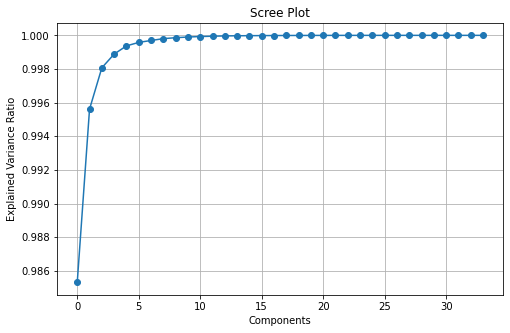

In [8]:
import matplotlib.pyplot as plt

# Scree Plot
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.title('Scree Plot')
plt.xlabel('Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

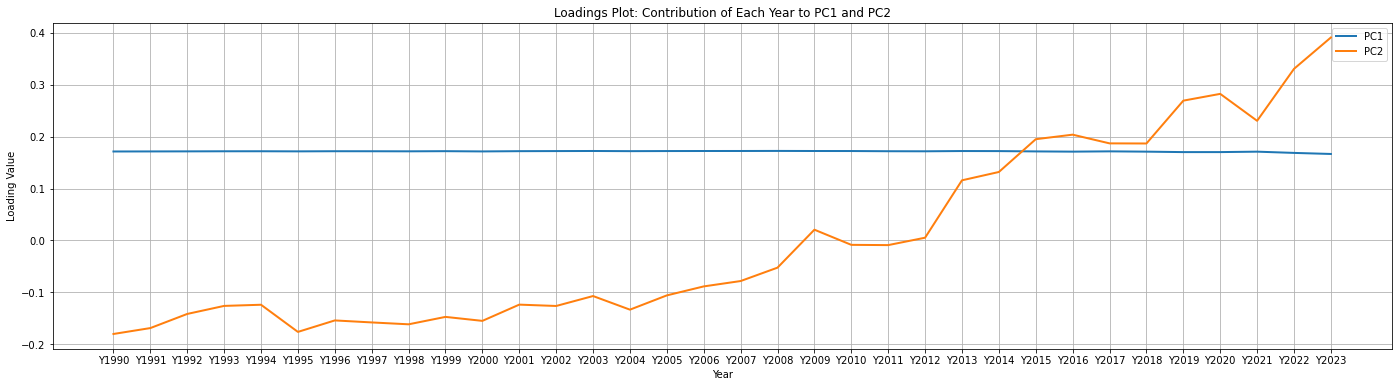

In [9]:
# Loadings Plot
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(explained_variance))],
    index=year_cols
)

plt.figure(figsize=(24,6))
plt.plot(loadings.index, loadings['PC1'], label='PC1', linewidth=2)
plt.plot(loadings.index, loadings['PC2'], label='PC2', linewidth=2)
plt.title('Loadings Plot: Contribution of Each Year to PC1 and PC2')
plt.xlabel('Year')
plt.ylabel('Loading Value')
plt.legend()
plt.grid(True)
plt.show()


### Data Preparation for KMeans

In [10]:
# Using only the first principal component
optimal_components = 1

# Creating DataFrame with just PC1 and the corresponding state labels
pca_combined_emissions = pd.DataFrame(
    pca_data[:, :optimal_components],
    columns=['PC1']
)

# Adding State column for reference
pca_combined_emissions['State'] = df_full_emissions['State']

# Data Overview
print(pca_combined_emissions.head())

         PC1       State
0   1.211719     Alabama
1  -2.598091      Alaska
2  -2.871715     Arizona
3  -0.949253    Arkansas
4  13.429545  California


### K-Means Clustering

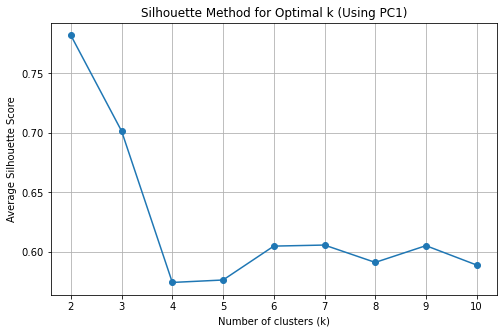

In [13]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans


X = pca_combined_emissions[['PC1']]

silhouette_scores = []

for k in range(2, 11):  
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42, algorithm='elkan')
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Method for Optimal k (Using PC1)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.grid(True)
plt.show()


In [18]:
# Clustering
kmeans_final = KMeans(n_clusters=3, n_init=10, random_state=42)
pca_combined_emissions['Cluster'] = kmeans_final.fit_predict(
    pca_combined_emissions.iloc[:, :optimal_components]
)
pca_combined_emissions

,PC1,State,Cluster
0,1.211719,Alabama,2
1,-2.598091,Alaska,2
2,-2.871715,Arizona,2
3,-0.949253,Arkansas,2
4,13.429545,California,0
5,-1.046629,Colorado,2
6,-4.094418,Connecticut,2
7,-3.606172,Delaware,2
8,-4.645587,District Of Columbia,2
9,0.206640,Florida,2


## - Specific Emmission Dataset

### Data Importation and Separation

In [19]:
# Path to your CSV file
file_path1 = "Cleaned_Combined_Emissions_Yearly.csv"

# IMporting Data
df_emissions = pd.read_csv(file_path1)

# Data Overview
df_emissions.head()

,Country,State,Year,Emission_Type,Emission
0,United States,Alabama,1990,Fossil_CO2,25871.992959
1,United States,Florida,1990,Fossil_CO2,24669.096219
2,United States,Georgia,1990,Fossil_CO2,32070.683542
3,United States,Hawaii,1990,Fossil_CO2,2731.980280
4,United States,Idaho,1990,Fossil_CO2,2634.310875


## - Fossil CO2 Dataset

### Getting Data

In [21]:
# Filtering for Fossil CO2
df_fossil = df_emissions[
    df_emissions['Emission_Type'].str.strip().str.lower() == 'fossil_co2'
].copy()
# Data Overview
df_fossil.head()

,Country,State,Year,Emission_Type,Emission
0,United States,Alabama,1990,Fossil_CO2,25871.992959
1,United States,Florida,1990,Fossil_CO2,24669.096219
2,United States,Georgia,1990,Fossil_CO2,32070.683542
3,United States,Hawaii,1990,Fossil_CO2,2731.980280
4,United States,Idaho,1990,Fossil_CO2,2634.310875


In [22]:
# - Data Preparation for PCA
# Converting to wide format
df_fossil = df_fossil.pivot(index=["Country", "State"], columns="Year", values="Emission")
# Removing the multi-index column name
df_fossil.columns.name = None
# Adding "Y" before each year column
df_fossil = df_fossil.rename(columns=lambda x: f"Y{x}")
# Reseting index
df_fossil = df_fossil.reset_index()
# Data Overview
df_fossil.head()

,Country,State,Y1990,Y1991,Y1992,Y1993,Y1994,Y1995,Y1996,Y1997,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
0,United States,Alabama,25871.992959,24661.539719,22147.333368,22609.102971,23139.477645,26303.509181,26224.193193,26964.295119,...,23910.739734,24739.486078,24839.793797,24493.311147,25385.720102,24896.929135,25814.138498,26318.363781,27215.717553,27096.384322
1,United States,Alaska,10459.716145,10259.698782,10013.158150,10002.743313,10047.172871,10410.822946,10575.721802,9700.913233,...,9037.243493,9695.754797,9927.504923,9714.188840,10133.521485,10221.556266,10033.266835,9734.286064,10406.736352,10335.749650
2,United States,Arizona,8036.211466,7403.614737,7419.662002,7905.332906,7951.894456,5095.913938,5155.402029,5961.646478,...,7093.313573,7013.799960,7116.266507,6743.459527,7349.589256,7428.468000,7093.993612,7607.711247,7552.835715,7643.433628
3,United States,Arkansas,17793.601899,16948.398292,16707.387279,17087.019635,17178.196614,21492.621085,21025.714304,20675.003456,...,18079.261977,17921.292608,17874.357877,17784.903123,18465.971662,18168.100476,17946.685879,18384.169142,18545.497094,18237.273942
4,United States,California,100087.496966,94220.571008,94898.921220,96519.203926,97674.558081,83559.012774,85001.976187,91830.342651,...,82040.083557,80054.827332,79937.371987,78534.209556,81134.579543,82013.209109,77967.071289,82347.743942,82824.977476,81548.258463


In [25]:
# Subseting the Year Columns (1990–2023)
year_cols = [col for col in df_fossil.columns if col.startswith('Y')]
fossil_emissions_1990_2023 = df_fossil[year_cols].copy()

# Scaling the data
scaled_fossil_emissions = scaler.fit_transform(fossil_emissions_1990_2023)

# - Principal Component Analysis
pca = PCA()
pca_data = pca.fit_transform(scaled_fossil_emissions)

# Getting Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)


Explained Variance Ratio: [9.91674308e-01 4.14212161e-03 2.40488977e-03 9.62444365e-04
 4.53182800e-04 1.86128231e-04 5.82186522e-05 4.18226335e-05
 2.59142303e-05 1.83457542e-05 8.07821653e-06 5.45135561e-06
 4.97704896e-06 3.95008439e-06 2.63268432e-06 1.70138638e-06
 1.57901637e-06 1.17221930e-06 9.31389883e-07 5.64351146e-07
 5.41147802e-07 3.36060438e-07 2.00616396e-07 1.62779463e-07
 1.01519746e-07 7.45035666e-08 4.84300844e-08 4.35495182e-08
 3.21492010e-08 2.27994530e-08 1.11386785e-08 5.27124047e-09
 3.35196967e-09 2.59845000e-09]


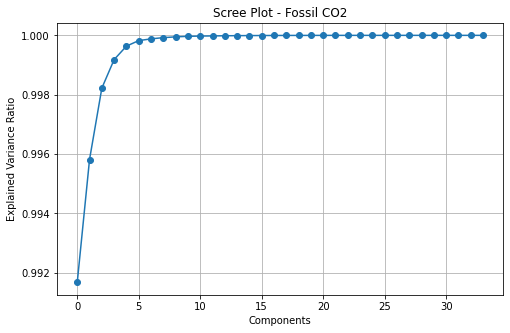

In [26]:
# Scree Plot 
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.title('Scree Plot - Fossil CO2')
plt.xlabel('Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

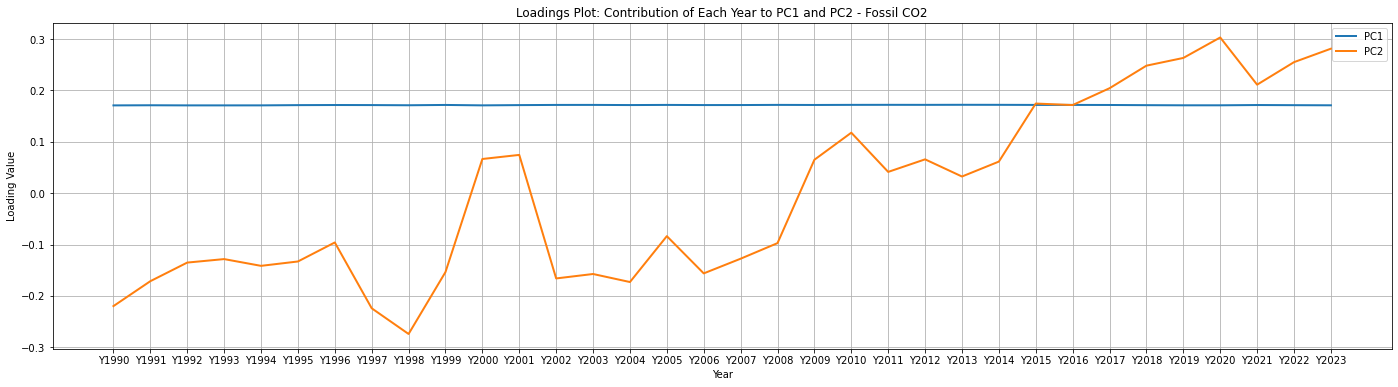

In [28]:
# Loadings Plot
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(explained_variance))],
    index=year_cols
)

plt.figure(figsize=(24,6))
plt.plot(loadings.index, loadings['PC1'], label='PC1', linewidth=2)
plt.plot(loadings.index, loadings['PC2'], label='PC2', linewidth=2)
plt.title('Loadings Plot: Contribution of Each Year to PC1 and PC2 - Fossil CO2')
plt.xlabel('Year')
plt.ylabel('Loading Value')
plt.legend()
plt.grid(True)
plt.show()


In [29]:
# - Data Preparation for KMeans Clustering

# Using only the first principal component
optimal_components = 1

# Creating DataFrame with just PC1 and the corresponding state labels
pca_fossil_emissions = pd.DataFrame(
    pca_data[:, :optimal_components],
    columns=['PC1']
)

# Adding State column for reference
pca_fossil_emissions['State'] = df_fossil['State']

# Data Overview
print(pca_fossil_emissions.head())

         PC1       State
0   2.148231     Alabama
1  -2.321353      Alaska
2  -3.192320     Arizona
3   0.152472    Arkansas
4  19.168770  California


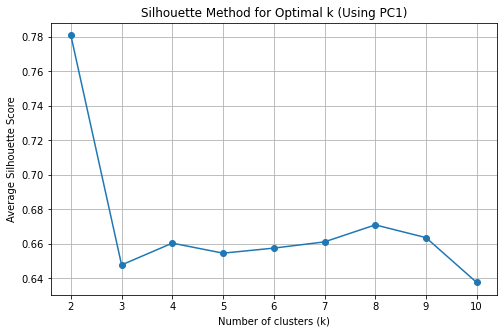

In [30]:
X = pca_fossil_emissions[['PC1']] 

silhouette_scores = []

for k in range(2, 11): 
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42, algorithm='elkan')
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Method for Optimal k (Using PC1)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.grid(True)
plt.show()


In [32]:
# Clustering
kmeans_final = KMeans(n_clusters=3, n_init=10, random_state=42)
pca_fossil_emissions['Cluster'] = kmeans_final.fit_predict(
    pca_fossil_emissions.iloc[:, :optimal_components]
)
pca_fossil_emissions

,PC1,State,Cluster
0,2.148231,Alabama,0
1,-2.321353,Alaska,1
2,-3.192320,Arizona,1
3,0.152472,Arkansas,0
4,19.168770,California,2
5,-1.997098,Colorado,1
6,-4.436491,Connecticut,1
7,-3.357885,Delaware,1
8,-5.022749,District of Columbia,1
9,0.386929,Florida,0


## - CH4 AR5 Dataset

### Getting Data

In [34]:
# Filtering for CH4 AR5
df_CH4 = df_emissions[
    df_emissions['Emission_Type'].str.strip().str.lower() == 'ch4_ar5'
].copy()
# Data Overview
df_CH4.head()

,Country,State,Year,Emission_Type,Emission
1734,United States,Alabama,1990,CH4_AR5,13086.892167
1735,United States,Florida,1990,CH4_AR5,1165.316125
1736,United States,Georgia,1990,CH4_AR5,1028.786881
1737,United States,Hawaii,1990,CH4_AR5,47.620448
1738,United States,Idaho,1990,CH4_AR5,562.059834


In [35]:
# - Data Preparation for PCA
# Converting to wide format
df_CH4 = df_CH4.pivot(index=["Country", "State"], columns="Year", values="Emission")
# Removing the multi-index column name
df_CH4.columns.name = None
# Adding "Y" before each year column
df_CH4 = df_CH4.rename(columns=lambda x: f"Y{x}")
# Reseting index
df_CH4 = df_CH4.reset_index()
# Data Overview
df_CH4.head()

,Country,State,Y1990,Y1991,Y1992,Y1993,Y1994,Y1995,Y1996,Y1997,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
0,United States,Alabama,13086.892167,11186.306721,11019.687012,10579.939152,10278.112031,9945.459387,9289.762460,9771.900727,...,4477.005453,4033.939899,5969.912443,5774.152379,4289.240865,3226.223501,2670.710129,3502.666521,3877.541293,3744.262796
1,United States,Alaska,2378.840799,2403.159164,2387.511197,2417.427180,2466.699638,2448.657248,2501.835199,2560.752786,...,3376.271854,3306.151369,5273.515435,3901.273063,2640.763194,3787.286787,4700.538682,5965.449081,8112.437471,5807.051083
2,United States,Arizona,1090.589520,1108.290942,1107.337623,1143.036851,1161.354095,1149.545266,1170.647286,1195.258927,...,1271.256887,1277.360566,1286.147941,1294.364167,1305.580304,1390.050114,1334.105776,1319.314656,1328.169514,1338.685969
3,United States,Arkansas,1842.680509,1869.945923,1863.953273,1910.936318,1950.961247,1943.105105,1963.753243,2018.256617,...,1751.806842,1749.203385,1808.012179,1836.387609,1778.272105,1746.219446,1736.408320,1746.097874,1751.811406,1773.954654
4,United States,California,3274.925930,3311.185260,3319.183135,3411.760078,3452.374690,3420.940129,3500.604606,3571.214860,...,3536.949874,3542.570518,3617.030101,3454.417266,3661.335236,3525.908008,4114.728071,4078.847527,4389.787798,4320.009170


In [36]:
# Subseting the Year Columns (1990–2023)
year_cols = [col for col in df_CH4.columns if col.startswith('Y')]
CH4_emissions_1990_2023 = df_CH4[year_cols].copy()

# Scaling the data
scaled_CH4_emissions = scaler.fit_transform(CH4_emissions_1990_2023)

# - Principal Component Analysis
pca = PCA()
pca_data = pca.fit_transform(scaled_CH4_emissions)

# Getting Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)


Explained Variance Ratio: [9.63673942e-01 3.03968396e-02 4.45925435e-03 6.56234578e-04
 3.26713538e-04 1.34072572e-04 1.22145068e-04 6.91532880e-05
 4.75851498e-05 4.18177525e-05 3.22058742e-05 1.80977278e-05
 8.09855155e-06 5.97117419e-06 4.03342005e-06 1.73504064e-06
 1.12176493e-06 3.80017830e-07 3.24660721e-07 1.58582151e-07
 8.36293498e-08 1.84831258e-08 7.81139542e-09 3.41897024e-09
 8.05221707e-10 4.75405644e-10 2.62116415e-10 6.41158882e-11
 5.48790838e-11 2.99892924e-11 5.95750211e-12 3.11682681e-12
 1.74449669e-12 3.41450702e-13]


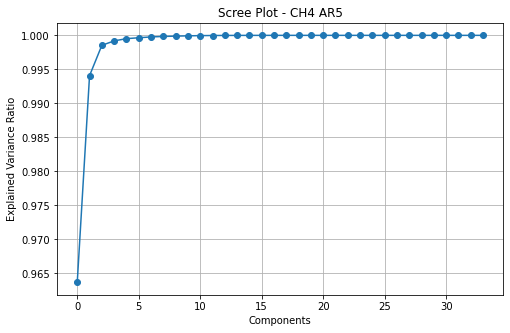

In [37]:
# Scree Plot 
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.title('Scree Plot - CH4 AR5')
plt.xlabel('Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

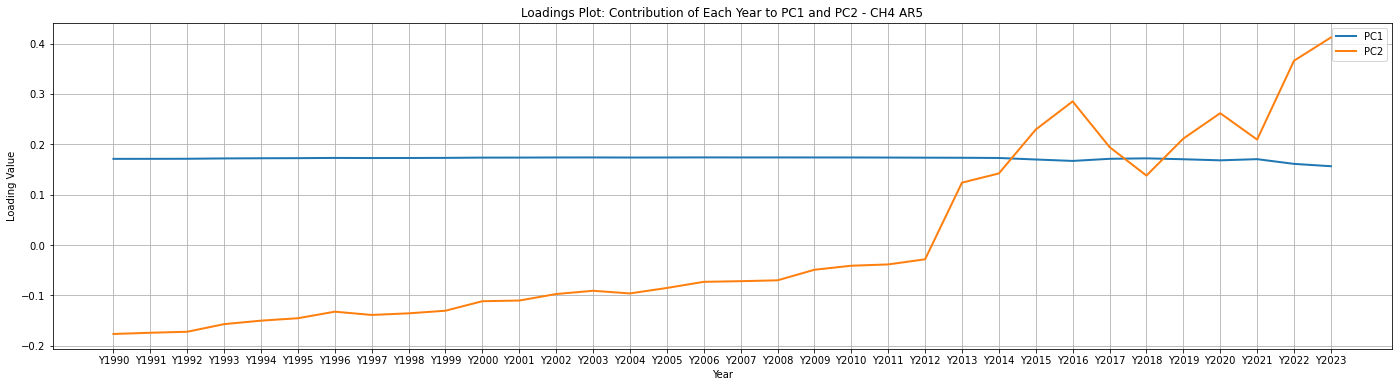

In [38]:
# Loadings Plot
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(explained_variance))],
    index=year_cols
)

plt.figure(figsize=(24,6))
plt.plot(loadings.index, loadings['PC1'], label='PC1', linewidth=2)
plt.plot(loadings.index, loadings['PC2'], label='PC2', linewidth=2)
plt.title('Loadings Plot: Contribution of Each Year to PC1 and PC2 - CH4 AR5')
plt.xlabel('Year')
plt.ylabel('Loading Value')
plt.legend()
plt.grid(True)
plt.show()


In [39]:
# - Data Preparation for KMeans Clustering

# Using only the first principal component
optimal_components = 1

# Creating DataFrame with just PC1 and the corresponding state labels
pca_CH4_emissions = pd.DataFrame(
    pca_data[:, :optimal_components],
    columns=['PC1']
)

# Adding State column for reference
pca_CH4_emissions['State'] = df_CH4['State']

# Data Overview
print(pca_CH4_emissions.head())

        PC1       State
0 -0.033032     Alabama
1 -1.344066      Alaska
2 -1.929808     Arizona
3 -1.692089    Arkansas
4 -1.171134  California


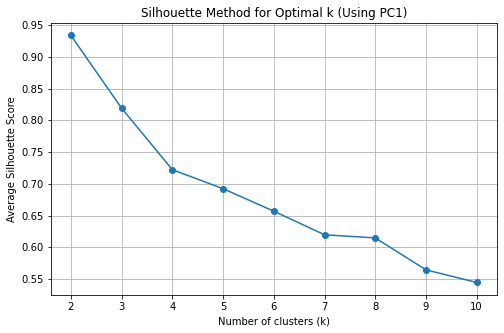

In [40]:
# - KMeans Clustering
# Getting optimal cluster sizes
X = pca_CH4_emissions[['PC1']] 

silhouette_scores = []

for k in range(2, 11): 
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42, algorithm='elkan')
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Method for Optimal k (Using PC1)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.grid(True)
plt.show()


In [41]:
# Clustering
kmeans_final = KMeans(n_clusters=4, n_init=10, random_state=42)
pca_CH4_emissions['Cluster'] = kmeans_final.fit_predict(
    pca_CH4_emissions.iloc[:, :optimal_components]
)
pca_CH4_emissions

,PC1,State,Cluster
0,-0.033032,Alabama,3
1,-1.344066,Alaska,0
2,-1.929808,Arizona,0
3,-1.692089,Arkansas,0
4,-1.171134,California,0
5,0.500526,Colorado,3
6,-2.241377,Connecticut,0
7,-2.286077,Delaware,0
8,-2.314398,District of Columbia,0
9,-1.886913,Florida,0


## - N2O AR5 Dataset

### Getting Data

In [42]:
# Filtering for N20 AR5
df_N2O = df_emissions[
    df_emissions['Emission_Type'].str.strip().str.lower() == 'n2o_ar5'
].copy()
# Data Overview
df_N2O.head()

,Country,State,Year,Emission_Type,Emission
3468,United States,Alabama,1990,N2O_AR5,973.951824
3469,United States,Florida,1990,N2O_AR5,2609.637921
3470,United States,Georgia,1990,N2O_AR5,2159.273087
3471,United States,Hawaii,1990,N2O_AR5,12.564917
3472,United States,Idaho,1990,N2O_AR5,34.035760


In [43]:
# - Data Preparation for PCA
# Converting to wide format
df_N2O = df_N2O.pivot(index=["Country", "State"], columns="Year", values="Emission")
# Removing the multi-index column name
df_N2O.columns.name = None
# Adding "Y" before each year column
df_N2O = df_N2O.rename(columns=lambda x: f"Y{x}")
# Reseting index
df_N2O = df_N2O.reset_index()
# Data Overview
df_N2O.head()

,Country,State,Y1990,Y1991,Y1992,Y1993,Y1994,Y1995,Y1996,Y1997,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
0,United States,Alabama,973.951824,966.061860,993.946624,1017.433011,1066.858675,1090.221157,1115.340572,1149.286446,...,1155.075239,1104.096592,1122.679675,1107.767134,1108.419953,1108.915969,1129.163169,1142.620432,1184.639090,1188.242302
1,United States,Alaska,18.711413,19.433642,17.401718,16.045322,16.068414,16.826944,17.091896,16.774849,...,38.012610,37.463020,37.977722,25.278912,26.499394,27.300156,20.733330,21.051744,21.852778,21.075489
2,United States,Arizona,185.944499,185.764730,190.820061,190.777779,197.348142,197.044209,203.638960,208.740146,...,223.578135,216.864061,221.562006,207.753902,213.045775,215.339065,211.493056,213.680036,219.418955,221.755069
3,United States,Arkansas,2449.195447,2272.014391,2055.380283,2376.385812,2524.314974,2998.103089,2925.461680,1535.072376,...,729.014212,698.555016,709.083487,706.858795,706.944408,706.332200,718.452303,727.165296,753.797335,755.764297
4,United States,California,963.736531,960.848938,986.129064,954.469778,977.987643,973.729870,1001.552773,1027.422180,...,986.195537,965.267692,977.662277,936.639090,950.667698,960.236958,943.623539,954.315599,969.440772,964.812556


In [44]:
# Subseting the Year Columns (1990–2023)
year_cols = [col for col in df_N2O.columns if col.startswith('Y')]
N2O_emissions_1990_2023 = df_N2O[year_cols].copy()

# Scaling the data
scaled_N2O_emissions = scaler.fit_transform(N2O_emissions_1990_2023)

# - Principal Component Analysis
pca = PCA()
pca_data = pca.fit_transform(scaled_N2O_emissions)

# Getting Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)

Explained Variance Ratio: [9.57134257e-01 4.18315188e-02 8.42364757e-04 9.67769334e-05
 4.40622783e-05 3.82351495e-05 9.57007122e-06 1.31862821e-06
 7.48798954e-07 5.30186293e-07 3.39420292e-07 1.23250067e-07
 4.38003810e-08 3.40715891e-08 2.67540351e-08 1.87410918e-08
 8.20359532e-09 5.15459173e-09 4.15475925e-09 3.16902668e-09
 2.55882344e-09 1.94578035e-09 1.75226215e-09 1.35572880e-09
 1.01595091e-09 6.88828955e-10 5.97073705e-10 2.53121252e-10
 2.15406413e-10 1.20953871e-10 1.13525062e-10 4.95717999e-11
 2.38179655e-11 1.29790950e-11]


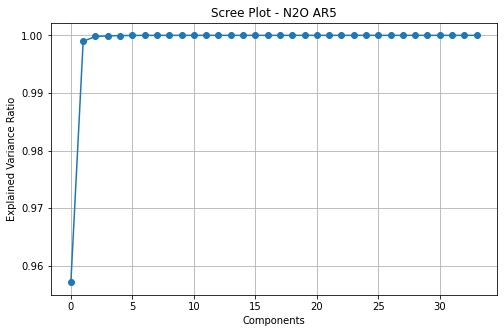

In [45]:
# Scree Plot 
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.title('Scree Plot - N2O AR5')
plt.xlabel('Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

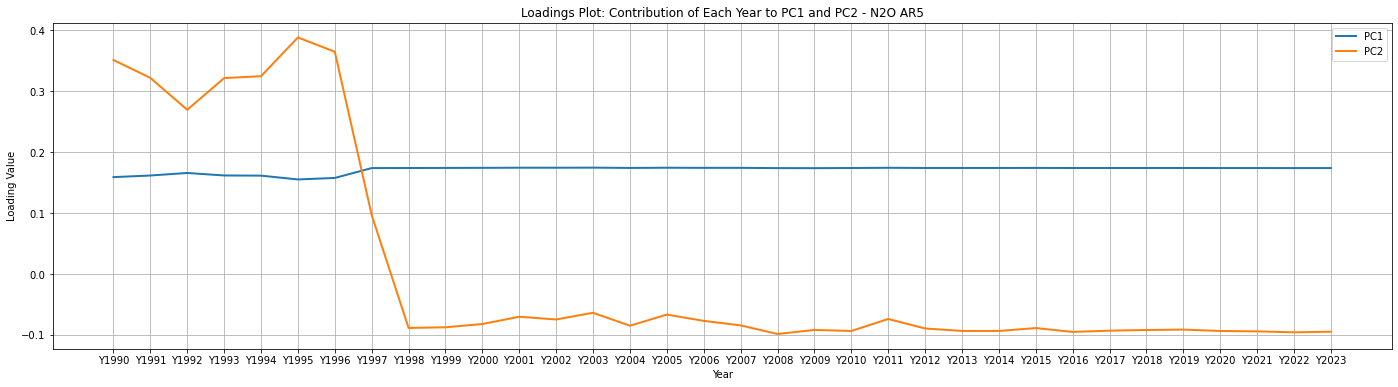

In [46]:
# Loadings Plot
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(explained_variance))],
    index=year_cols
)

plt.figure(figsize=(24,6))
plt.plot(loadings.index, loadings['PC1'], label='PC1', linewidth=2)
plt.plot(loadings.index, loadings['PC2'], label='PC2', linewidth=2)
plt.title('Loadings Plot: Contribution of Each Year to PC1 and PC2 - N2O AR5')
plt.xlabel('Year')
plt.ylabel('Loading Value')
plt.legend()
plt.grid(True)
plt.show()


In [47]:
# - Data Preparation for KMeans Clustering

# Using only the first principal component
optimal_components = 1

# Creating DataFrame with just PC1 and the corresponding state labels
pca_N2O_emissions = pd.DataFrame(
    pca_data[:, :optimal_components],
    columns=['PC1']
)

# Adding State column for reference
pca_N2O_emissions['State'] = df_N2O['State']

# Data Overview
print(pca_N2O_emissions.head())

        PC1       State
0  5.576824     Alabama
1 -4.030703      Alaska
2 -2.424727     Arizona
3  4.896076    Arkansas
4  4.371873  California


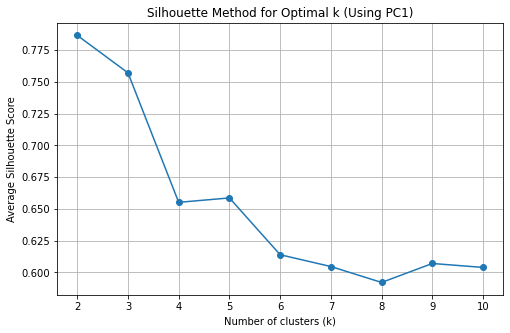

In [48]:
# - KMeans Clustering
# Getting optimal cluster sizes
X = pca_N2O_emissions[['PC1']] 

silhouette_scores = []

for k in range(2, 11): 
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42, algorithm='elkan')
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Method for Optimal k (Using PC1)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.grid(True)
plt.show()

In [49]:
# Clustering
kmeans_final = KMeans(n_clusters=3, n_init=10, random_state=42)
pca_N2O_emissions['Cluster'] = kmeans_final.fit_predict(
    pca_N2O_emissions.iloc[:, :optimal_components]
)
pca_N2O_emissions

,PC1,State,Cluster
0,5.576824,Alabama,2
1,-4.030703,Alaska,0
2,-2.424727,Arizona,0
3,4.896076,Arkansas,2
4,4.371873,California,2
5,-1.497966,Colorado,0
6,-3.951615,Connecticut,0
7,-4.071962,Delaware,0
8,-4.216047,District of Columbia,0
9,4.849651,Florida,2


## - F-Gases AR5 Dataset

### Getting Data

In [51]:
# Filtering for F-Gases AR5
df_FG = df_emissions[
    df_emissions['Emission_Type'].str.strip().str.lower() == 'f_gases_ar5'
].copy()
# Data Overview
df_FG.head()

,Country,State,Year,Emission_Type,Emission
5202,United States,Alabama,1990,F_gases_AR5,2409.102893
5203,United States,Florida,1990,F_gases_AR5,5997.748130
5204,United States,Georgia,1990,F_gases_AR5,4052.806192
5205,United States,Hawaii,1990,F_gases_AR5,288.229752
5206,United States,Idaho,1990,F_gases_AR5,534.048684


In [52]:
# - Data Preparation for PCA
# Converting to wide format
df_FG = df_FG.pivot(index=["Country", "State"], columns="Year", values="Emission")
# Removing the multi-index column name
df_FG.columns.name = None
# Adding "Y" before each year column
df_FG = df_FG.rename(columns=lambda x: f"Y{x}")
# Reseting index
df_FG = df_FG.reset_index()
# Data Overview
df_FG.head()

,Country,State,Y1990,Y1991,Y1992,Y1993,Y1994,Y1995,Y1996,Y1997,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
0,United States,Alabama,2409.102893,2403.910387,2601.409136,2739.045291,2957.539216,3373.483826,3557.929417,3708.045468,...,3645.110510,3656.464452,3645.224573,3666.040857,3623.337308,3725.456158,3805.560635,3937.347448,4041.405028,4170.864740
1,United States,Alaska,200.711362,199.588373,217.594051,218.825747,238.798519,274.289431,289.224832,302.263420,...,265.078313,266.074644,266.321503,267.932931,262.446423,269.857711,275.852430,285.405945,292.942517,292.830061
2,United States,Arizona,2084.325240,2072.663350,2259.646730,2438.387047,2660.944716,3056.421855,3222.847830,3368.137514,...,3669.793193,3683.586587,3687.004141,3709.313058,3796.912242,3904.134172,3990.862056,4129.076394,4238.110848,4421.081987
3,United States,Arkansas,1345.806013,1346.562698,1448.673818,1540.311000,1649.393457,1870.917739,1973.546735,2052.236995,...,2005.878584,2011.071260,1998.304820,2009.156104,2001.999274,2058.332764,2101.403144,2174.170377,2231.668623,2306.623619
4,United States,California,17659.755582,17454.303845,18947.352684,19545.616259,21046.798328,23904.685146,25502.408935,26400.476414,...,22595.261098,22695.047837,22783.171207,22858.743384,22632.073472,23183.820169,23683.836370,24595.646427,25240.327899,25632.548712


In [53]:
# Subseting the Year Columns (1990–2023)
year_cols = [col for col in df_FG.columns if col.startswith('Y')]
FG_emissions_1990_2023 = df_FG[year_cols].copy()

# Scaling the data
scaled_FG_emissions = scaler.fit_transform(FG_emissions_1990_2023)

# - Principal Component Analysis
pca = PCA()
pca_data = pca.fit_transform(scaled_FG_emissions)

# Getting Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)

Explained Variance Ratio: [9.88786540e-01 1.09279715e-02 2.06691744e-04 3.76921830e-05
 2.52506213e-05 9.28445697e-06 3.29968093e-06 1.44480263e-06
 1.19992899e-06 4.01276181e-07 2.14778432e-07 6.26749922e-09
 3.02351418e-09 2.08061483e-10 6.61220530e-30 5.35659301e-30
 4.69838474e-30 1.62886970e-30 1.24102302e-30 1.21303381e-30
 1.15783353e-30 9.84264795e-31 8.76959215e-31 7.30367041e-31
 6.03538001e-31 5.40549812e-31 5.10966767e-31 4.00944530e-31
 2.93704772e-31 1.76905830e-31 1.43330747e-31 7.79895832e-32
 5.60682913e-32 2.35796888e-32]


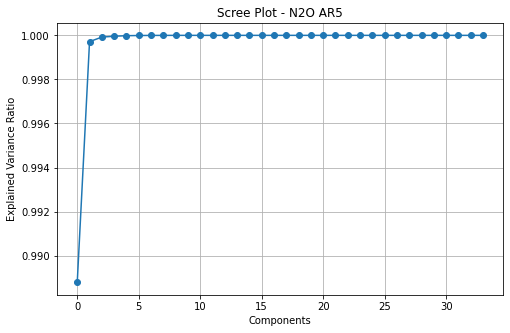

In [54]:
# Scree Plot 
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.title('Scree Plot - N2O AR5')
plt.xlabel('Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

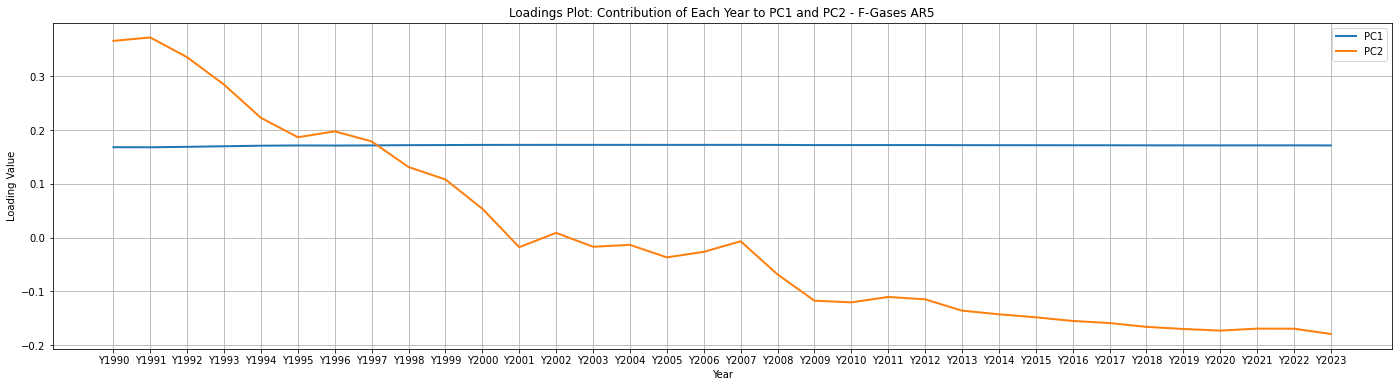

In [55]:
# Loadings Plot
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(explained_variance))],
    index=year_cols
)

plt.figure(figsize=(24,6))
plt.plot(loadings.index, loadings['PC1'], label='PC1', linewidth=2)
plt.plot(loadings.index, loadings['PC2'], label='PC2', linewidth=2)
plt.title('Loadings Plot: Contribution of Each Year to PC1 and PC2 - F-Gases AR5')
plt.xlabel('Year')
plt.ylabel('Loading Value')
plt.legend()
plt.grid(True)
plt.show()


In [56]:
# - Data Preparation for KMeans Clustering

# Using only the first principal component
optimal_components = 1

# Creating DataFrame with just PC1 and the corresponding state labels
pca_FG_emissions = pd.DataFrame(
    pca_data[:, :optimal_components],
    columns=['PC1']
)

# Adding State column for reference
pca_FG_emissions['State'] = df_FG['State']

# Data Overview
print(pca_FG_emissions.head())

         PC1       State
0  -0.239293     Alabama
1  -4.813365      Alaska
2  -0.391968     Arizona
3  -2.453433    Arkansas
4  27.413939  California


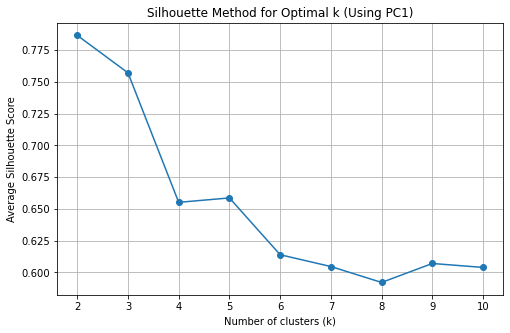

In [57]:
# - KMeans Clustering
# Getting optimal cluster sizes
X = pca_N2O_emissions[['PC1']] 

silhouette_scores = []

for k in range(2, 11): 
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42, algorithm='elkan')
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Method for Optimal k (Using PC1)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.grid(True)
plt.show()

In [58]:
# Clustering
kmeans_final = KMeans(n_clusters=3, n_init=10, random_state=42)
pca_FG_emissions['Cluster'] = kmeans_final.fit_predict(
    pca_FG_emissions.iloc[:, :optimal_components]
)
pca_FG_emissions

,PC1,State,Cluster
0,-0.239293,Alabama,1
1,-4.813365,Alaska,1
2,-0.391968,Arizona,1
3,-2.453433,Arkansas,1
4,27.413939,California,2
5,-0.920400,Colorado,1
6,-3.476637,Connecticut,1
7,-4.381868,Delaware,1
8,-5.042878,District of Columbia,1
9,7.411791,Florida,0


## - Combining and Saving Clustered Dataset

In [67]:
Clustered_emissions = pca_combined_emissions
Clustered_emissions = Clustered_emissions.drop(columns = ['PC1'])
Clustered_emissions = Clustered_emissions.rename(columns={'Cluster': 'Combined_Emissions_Cluster'})
Clustered_emissions['Fossil_CO2_Cluster'] = pca_fossil_emissions['Cluster']
Clustered_emissions['CH4_AR5_Cluster'] = pca_CH4_emissions['Cluster']
Clustered_emissions['N2O_AR5_Cluster'] = pca_N2O_emissions['Cluster']
Clustered_emissions['FGases_AR5_Cluster'] = pca_FG_emissions['Cluster']
Clustered_emissions

,State,Combined_Emissions_Cluster,Fossil_CO2_Cluster,CH4_AR5_Cluster,N2O_AR5_Cluster,FGases_AR5_Cluster
0,Alabama,2,0,3,2,1
1,Alaska,2,1,0,0,1
2,Arizona,2,1,0,0,1
3,Arkansas,2,0,0,2,1
4,California,0,2,0,2,2
5,Colorado,2,1,3,0,1
6,Connecticut,2,1,0,0,1
7,Delaware,2,1,0,0,1
8,District Of Columbia,2,1,0,0,1
9,Florida,2,0,0,2,0


In [68]:
Clustered_emissions.to_csv("Clustered_emissions.csv", index=False)